

# CIBMTR - Equity in post-HCT Survival Predictions
### Introduction

This notebook is for the [Equity post-HCT survival predictions competition](https://www.kaggle.com/competitions/equity-post-HCT-survival-predictions). The final private leaderboard score is **0.69261**, placing me at **773 / 3327** participants. The top solution achieves **0.70127**, so it is quite close!

**High-level strategy**:
1. **Feature Engineering & Splitting**. We create separate classification/regression pipelines.
2. **Stage 1**: Classification models (binary `efs=1` vs `efs=0`) to estimate the probability of an event.
3. **Stage 2**: Regression models (e.g. log EFS time, Kaplan-Meier, etc.) to model the timing or hazard dimension.
4. **Merging**: We combine the classification & regression outputs in an aggregator, searching for best parameters via Optuna.

**Regarding the Negative Sign**:  
- The official competition scoring function uses `-prediction` because it expects “risk scores,” i.e. bigger = *more* risk = *earlier event*. 

```python
c_index_race = concordance_index(merged_df_race[interval_label],
                                 -merged_df_race[prediction_label], # negative sign here
                                 merged_df_race[event_label])
```

- The regression models produce *longer survival* for bigger predictions. That’s the opposite orientation.  
- In some prior attempts, I included the negative sign in `score(...)` or in the aggregator. Ultimately, we want to make sure that the final scoring sees “larger = riskier.” 
- Another approach is to **remove** the negative in the metric and **manually flip** survival-based models in the aggregator. Either way can be correct, just be consistent with the competition’s expectation.

```python
c_index_race = concordance_index(merged_df_race[interval_label],
                                 merged_df_race[prediction_label], # no negative
                                 merged_df_race[event_label])
```

The best solution so far uses the competition's metric and the aggregator parameters found by Optuna with flipping to KM and Cox targets, yielding the final LB score of 0.69261. 


### Libaries

**Note:** 
To compute the competition metric in a Kaggle notebook, you must attach Kaggle's metric notebook and add the following notebook as an input on Kaggle since the competition notebooks must have internet turned off (https://www.kaggle.com/code/cdeotte/pip-install-lifelines). This notebook contains WHL files to allow you to pip install with internet off. 

In [1]:
# !pip install /kaggle/input/pip-install-lifelines/autograd-1.7.0-py3-none-any.whl -q
# !pip install /kaggle/input/pip-install-lifelines/autograd-gamma-0.5.0.tar.gz -q
# !pip install /kaggle/input/pip-install-lifelines/interface_meta-1.3.0-py3-none-any.whl -q
# !pip install /kaggle/input/pip-install-lifelines/formulaic-1.0.2-py3-none-any.whl -q
# !pip install /kaggle/input/pip-install-lifelines/lifelines-0.30.0-py3-none-any.whl -q

In [1]:
import sys
import os
# if you are running this in kaggle, make a kaggle dataset with all python files 
# then you can append it here and remove src. from import statements
# sys.path.append("/kaggle/input/woohoo") 

# add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
from src.config import CFG
from src.feature_engineering import FE
from src.train import MD, train_and_predict
from src.ensemble import optimize_merge_params
import gc
import numpy as np
import torch

In [2]:
# check GPU for PyTorch
print("PyTorch CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))

PyTorch CUDA Available: True
Using GPU: NVIDIA GeForce RTX 3070 Ti


### Feature Engineering

In [3]:
fe = FE(batch_size=CFG.batch_size)

# tree models
train_tree = fe.feature_engineering_pipeline(CFG.train_path, "tree", train=True)
test_tree = fe.feature_engineering_pipeline(CFG.test_path, "tree", train=False)
cat_cols_tree = train_tree['feature_cat']  
print(len(cat_cols_tree))

# CoxResNet
train_cox = fe.feature_engineering_pipeline(CFG.train_path, "coxresnet", train=True)
test_cox = fe.feature_engineering_pipeline(CFG.test_path, "coxresnet", train=False)
cat_cols_cox = train_cox['feature_cat']  
print(len(cat_cols_cox))

35
34


In [4]:
train_tree

{'X':           ID dri_score psych_disturb cyto_score diabetes  hla_match_c_high  \
 0          0         7             0          7        0               2.0   
 1          1         2             0          1        0               2.0   
 2          2         7             0          7        0               2.0   
 3          3         0             0          1        0               2.0   
 4          4         0             0          7        0               2.0   
 ...      ...       ...           ...        ...      ...               ...   
 28795  28795         3             2          0        0               2.0   
 28796  28796         0             0          5        3               1.0   
 28797  28797         9             2          5        2               2.0   
 28798  28798         7             0          5        0               1.0   
 28799  28799         8             0          7        0               2.0   
 
        hla_high_res_8 tbi_status arrhythmia 

In [5]:
test_tree

{'X':       ID dri_score psych_disturb cyto_score diabetes  hla_match_c_high  \
 0  28800         7             0          7        0               2.0   
 1  28801         2             0          1        0               2.0   
 2  28802         7             0          7        0               2.0   
 
    hla_high_res_8 tbi_status arrhythmia  hla_low_res_6  ... hepatic_mild  \
 0             8.0          0          0            6.0  ...            0   
 1             8.0          6          0            6.0  ...            0   
 2             8.0          0          0            6.0  ...            0   
 
   tce_div_match donor_related melphalan_dose hla_low_res_8  cardiac  \
 0             4             3              1           8.0        0   
 1             3             1              1           8.0        0   
 2             3             1              1           8.0        0   
 
   hla_match_drb1_high  pulm_moderate  hla_low_res_10 target_norm  
 0                 2.0   

In [6]:
train_cox

{'X':           ID  dri_score  psych_disturb  cyto_score  diabetes  \
 0          0          7              0           7         0   
 1          1          2              0           1         0   
 2          2          7              0           7         0   
 3          3          0              0           1         0   
 4          4          0              0           7         0   
 ...      ...        ...            ...         ...       ...   
 28795  28795          3              2           0         0   
 28796  28796          0              0           5         3   
 28797  28797          9              2           5         2   
 28798  28798          7              0           5         0   
 28799  28799          8              0           7         0   
 
        hla_match_c_high  hla_high_res_8  tbi_status  arrhythmia  \
 0              0.488048        0.610215           0           0   
 1              0.488048        0.610215           6           0   
 2       

In [7]:
test_cox

{'X':       ID  dri_score  psych_disturb  cyto_score  diabetes  hla_match_c_high  \
 0  28800          1              0           1         0          0.488048   
 1  28801          0              0           0         0          0.488048   
 2  28802          1              0           1         0          0.488048   
 
    hla_high_res_8  tbi_status  arrhythmia  hla_low_res_6  ...  \
 0        0.610215           0           0       0.649549  ...   
 1        0.610215           1           0       0.649549  ...   
 2        0.610215           0           0       0.649549  ...   
 
    melphalan_dose_N/A, Mel not given  melphalan_dose_Unknown  cardiac_No  \
 0                                1.0                     0.0         1.0   
 1                                1.0                     0.0         1.0   
 2                                1.0                     0.0         1.0   
 
    cardiac_Not done  cardiac_Unknown  cardiac_Yes  pulm_moderate_No  \
 0               0.0         

### Column Alignment & Feature Consistency

After feature engineering, our train and test sets sometimes have slightly different columns (due to missing categories or transformations). We fix this via a simple helper function. This ensures no shape mismatch between train & test features before building our final pipeline.

In [8]:
def align_columns(train_df, test_df):
    missing_cols = set(train_df.columns) - set(test_df.columns)
    extra_cols = set(test_df.columns) - set(train_df.columns)
    print("Missing Columns in Train DataFrame: ", missing_cols)
    print("Extra Columns in Test DataFrame: ", extra_cols)

    # add missing cols in test set 
    for col in missing_cols:
        test_df[col] = -1

    test_df = test_df.drop(columns=extra_cols) # remove extra cols from test set
    test_df = test_df[train_df.columns] # identical column ordering

    return test_df

test_tree['X'] = align_columns(train_tree['X'], test_tree['X']) # Tree models features alignment
test_cox['X'] = align_columns(train_cox['X'], test_cox['X']) # CoxResNet features alignment

# make sure there are no shape mismathces btw train/test
assert train_tree['X'].shape[1] == test_tree['X'].shape[1]
assert train_cox['X'].shape[1] == test_cox['X'].shape[1]

Missing Columns in Train DataFrame:  {'km_survival_prob', 'log_efs_time', 'ranked_efs_time', 'neg_exp_na_cum_hazard', 'na_cum_hazard'}
Extra Columns in Test DataFrame:  set()
Missing Columns in Train DataFrame:  {'km_survival_prob', 'log_efs_time', 'ranked_efs_time', 'neg_exp_na_cum_hazard', 'na_cum_hazard'}
Extra Columns in Test DataFrame:  set()


### Building DataFrames for Model Training

Below, we merge our feature matrices (`X`) with the target columns (`efs`, `efs_time`, and `race_group`). We also convert single-column DataFrames into Series with `.squeeze()`, ensuring correct data types for training. We do this for each pipeline (tree vs. CoxResNet) so both have consistent targets and features in a single DataFrame.



In [9]:
# convert single-col DataFrame to Series with squeeze for .str methods to work 
train_tree_df = pd.concat([train_tree['X'], 
                           train_tree['efs'].astype(int).squeeze(),  
                           train_tree['efs_time'].astype(float).squeeze(),
                           train_tree['race_group'].astype(str).squeeze()], axis=1)

md_tree = MD(CFG.color, train_tree_df, cat_cols=cat_cols_tree, early_stop=CFG.early_stop, n_splits=CFG.n_splits)

train_cox_df = pd.concat([train_cox['X'],
                          train_cox['efs'].astype(int).squeeze(),
                          train_cox['efs_time'].astype(float).squeeze(),
                          train_cox['race_group'].astype(str).squeeze()], axis=1)

md_cox = MD(CFG.color, train_cox_df, cat_cols=cat_cols_cox, early_stop=CFG.early_stop, n_splits=CFG.n_splits)

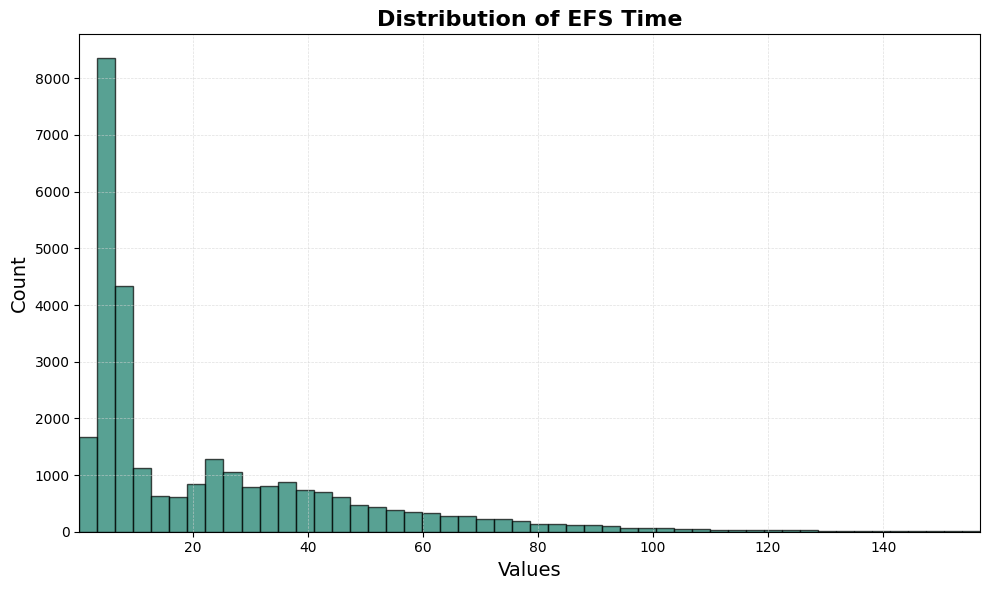

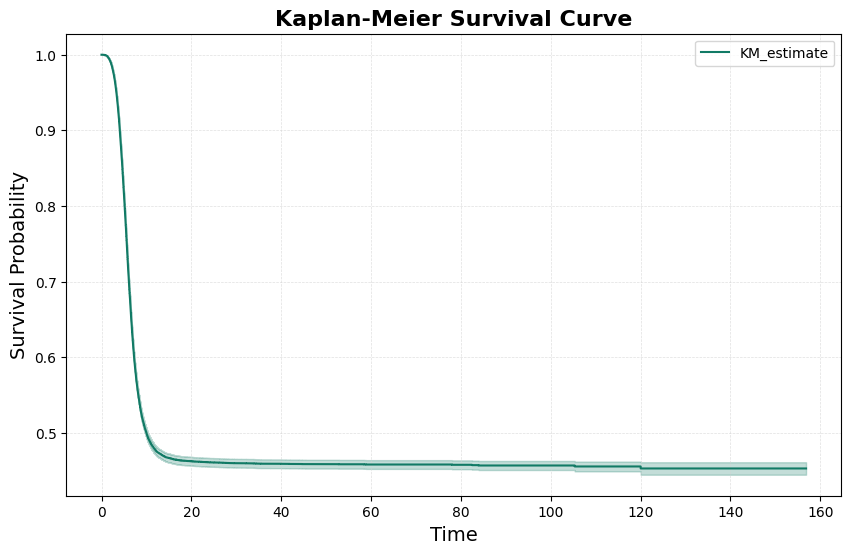

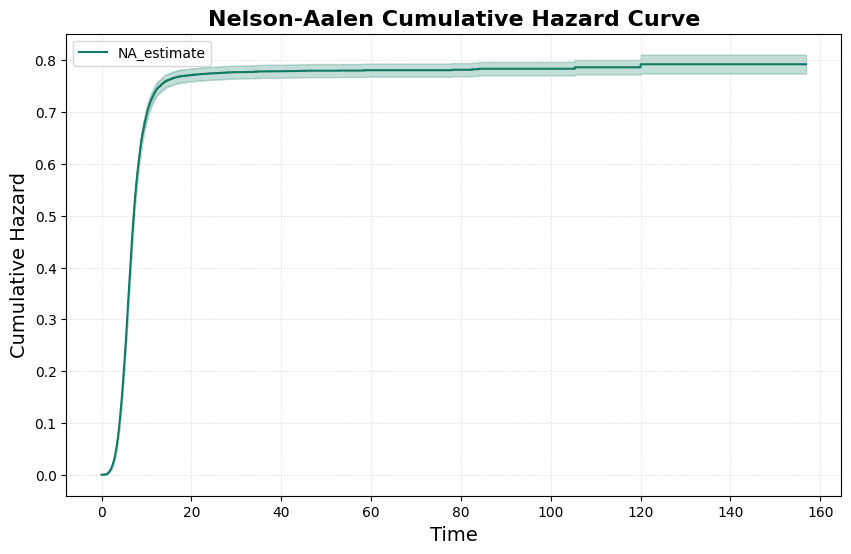

In [10]:
# 1. distribution of efs_time
md_tree.eda.distribution_plot(col='efs_time', title='Distribution of EFS Time', bins=50)

# 2. Kaplan-Meier survival curve across the entire dataset
md_tree.eda.plot_kaplan_meier(time_col='efs_time', event_col='efs')

# 3. Nelson-Aalen cumulative hazard curve
md_tree.eda.plot_nelson_aalen(time_col='efs_time', event_col='efs')



Fold 1
Fold 1 ROC AUC: 0.7578, Log Loss: 0.5818

Fold 2
Fold 2 ROC AUC: 0.7589, Log Loss: 0.5798

Fold 3
Fold 3 ROC AUC: 0.7472, Log Loss: 0.5896

Fold 4
Fold 4 ROC AUC: 0.7536, Log Loss: 0.5855

Fold 5
Fold 5 ROC AUC: 0.7543, Log Loss: 0.5861


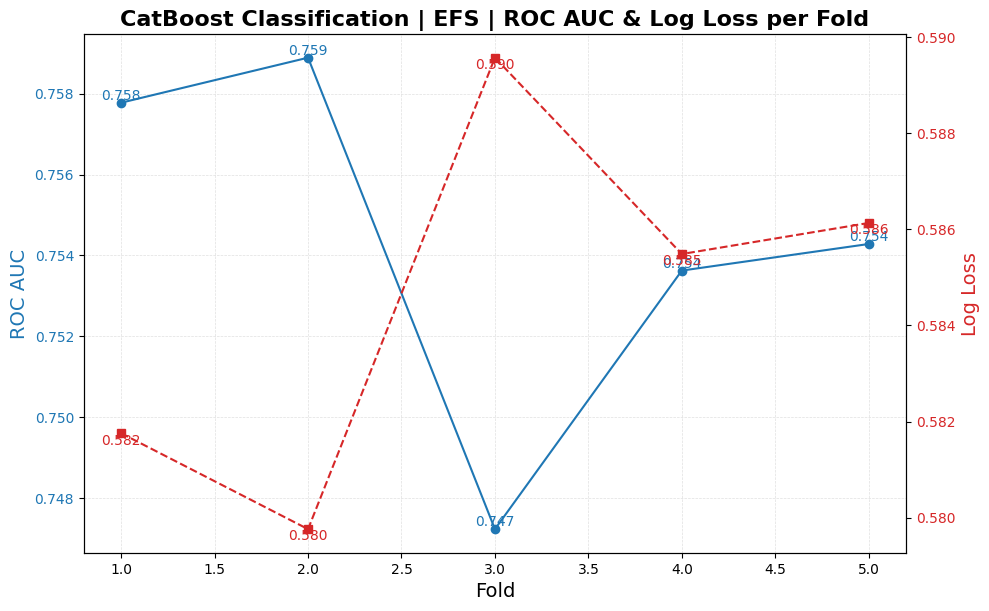

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
[0]	validation_0-logloss:0.68769
[1]	validation_0-logloss:0.68701
[2]	validation_0-logloss:0.68204
[3]	validation_0-logloss:0.68058
[4]	validation_0-logloss:0.67789
[5]	validation_0-logloss:0.67560
[6]	validation_0-logloss:0.67218
[7]	validation_0-logloss:0.67032
[8]	validation_0-logloss:0.66729
[9]	validation_0-logloss:0.66671
[10]	validation_0-logloss:0.66480
[11]	validation_0-logloss:0.66413
[12]	validation_0-logloss:0.66203
[13]	validation_0-logloss:0.66032
[14]	validation_0-logloss:0.65931
[15]	validation_0-logloss:0.65674
[16]	validation_0-logloss:0.65534
[17]	validation_0-logloss:0.65371
[18]	validation_0-logloss:0.65231
[19]	validation_0-logloss:0.65120
[20]	validation_0-logloss:0.65036
[21]	validation_0-logloss:0.64894
[22]	validation_0-logloss:0.64823
[23]	validation_0-logloss:0.64731
[24]	validation_0-lo

c:\Users\mattg\kaggle_env\lib\site-packages\xgboost\core.py:158: UserWarning: [00:05:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[14]	validation_0-logloss:0.65873
[15]	validation_0-logloss:0.65611
[16]	validation_0-logloss:0.65446
[17]	validation_0-logloss:0.65262
[18]	validation_0-logloss:0.65086
[19]	validation_0-logloss:0.64968
[20]	validation_0-logloss:0.64852
[21]	validation_0-logloss:0.64707
[22]	validation_0-logloss:0.64602
[23]	validation_0-logloss:0.64489
[24]	validation_0-logloss:0.64417
[25]	validation_0-logloss:0.64328
[26]	validation_0-logloss:0.64234
[27]	validation_0-logloss:0.64170
[28]	validation_0-logloss:0.64037
[29]	validation_0-logloss:0.63973
[30]	validation_0-logloss:0.63882
[31]	validation_0-logloss:0.63808
[32]	validation_0-logloss:0.63654
[33]	validation_0-logloss:0.63585
[34]	validation_0-logloss:0.63504
[35]	validation_0-logloss:0.63420
[36]	validation_0-logloss:0.63347
[37]	validation_0-logloss:0.63285
[38]	validation_0-logloss:0.63216
[39]	validation_0-logloss:0.63149
[40]	validation_0-logloss:0.63076
[41]	validation_0-logloss:0.62972
[42]	validation_0-logloss:0.62896
[43]	validatio

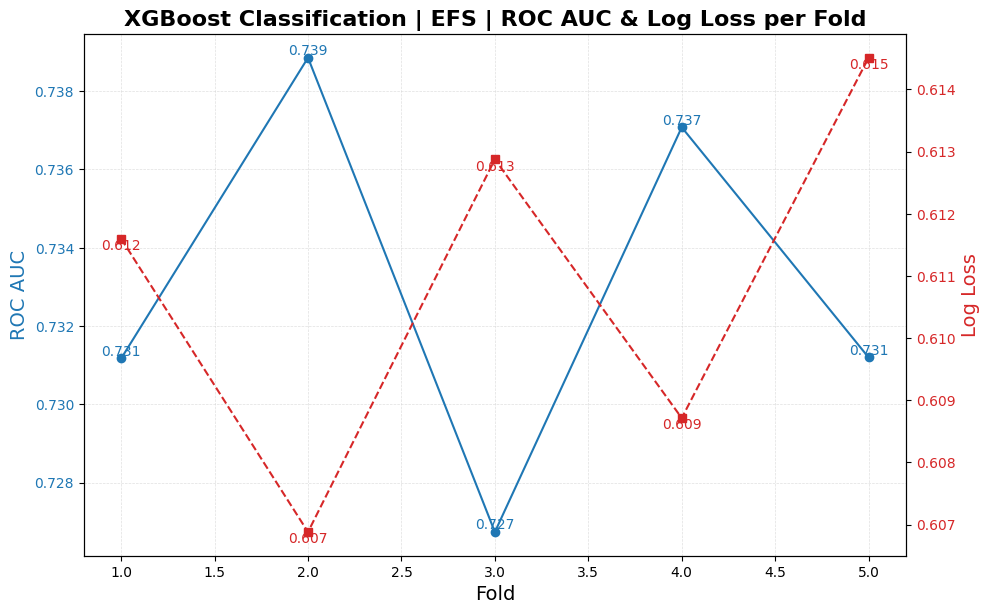

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 1 ROC AUC: 0.7547, Log Loss: 0.5853

Fold 2


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 2 ROC AUC: 0.7579, Log Loss: 0.5817

Fold 3


...

Fold 3 ROC AUC: 0.7469, Log Loss: 0.5889

Fold 4


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 4 ROC AUC: 0.7524, Log Loss: 0.5865

Fold 5


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 5 ROC AUC: 0.7522, Log Loss: 0.5886


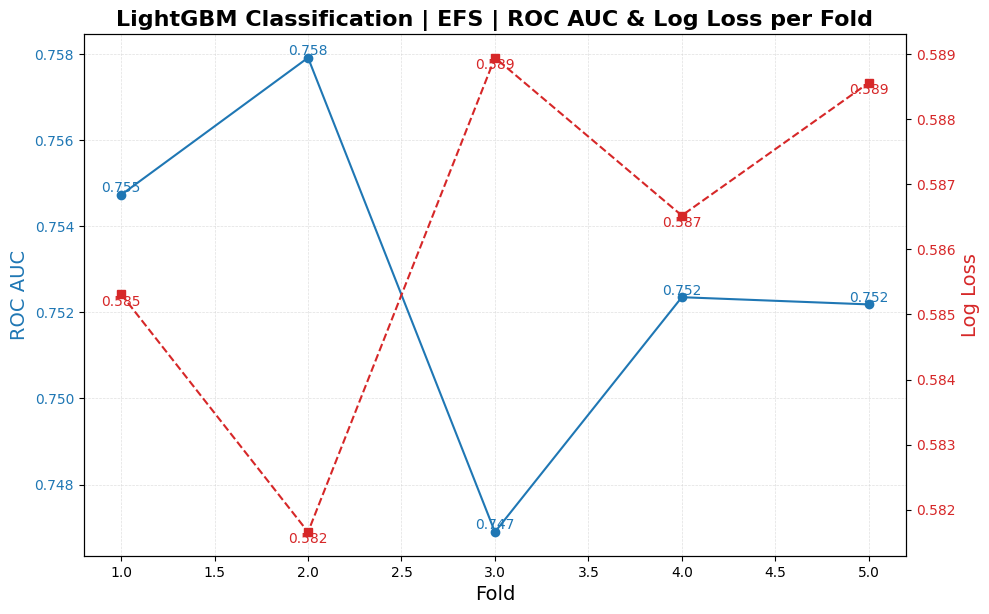

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 ROC AUC: 0.7496, Log Loss: 0.5892

Fold 2
Fold 2 ROC AUC: 0.7581, Log Loss: 0.5822

Fold 3
Fold 3 ROC AUC: 0.7415, Log Loss: 0.5947

Fold 4
Fold 4 ROC AUC: 0.7444, Log Loss: 0.5916

Fold 5
Fold 5 ROC AUC: 0.7466, Log Loss: 0.5920


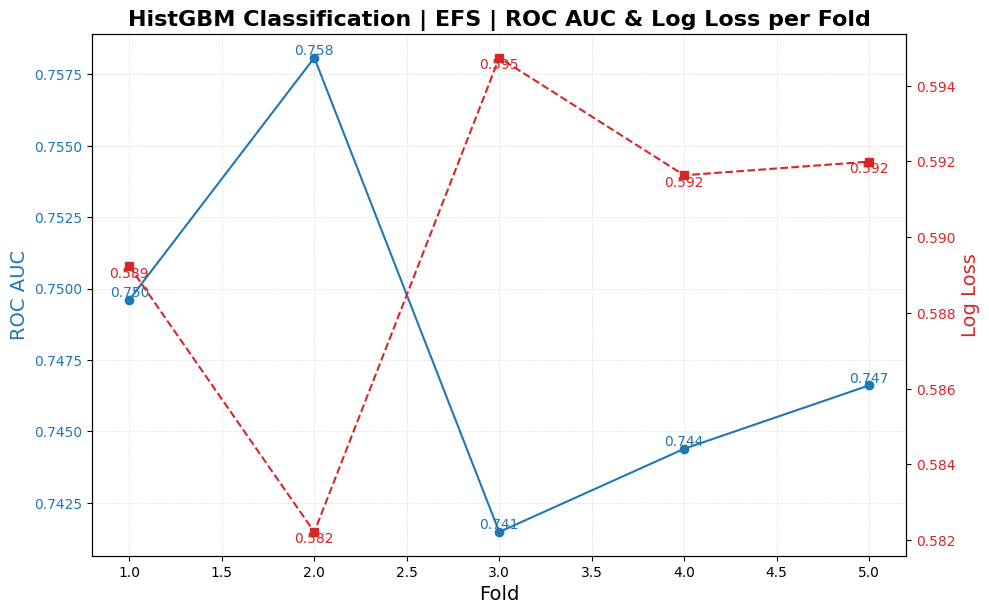

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0863

Fold 2
Fold 2 Stratified C-Index: 0.0891

Fold 3
Fold 3 Stratified C-Index: 0.0925

Fold 4
Fold 4 Stratified C-Index: 0.0881

Fold 5
Fold 5 Stratified C-Index: 0.0869


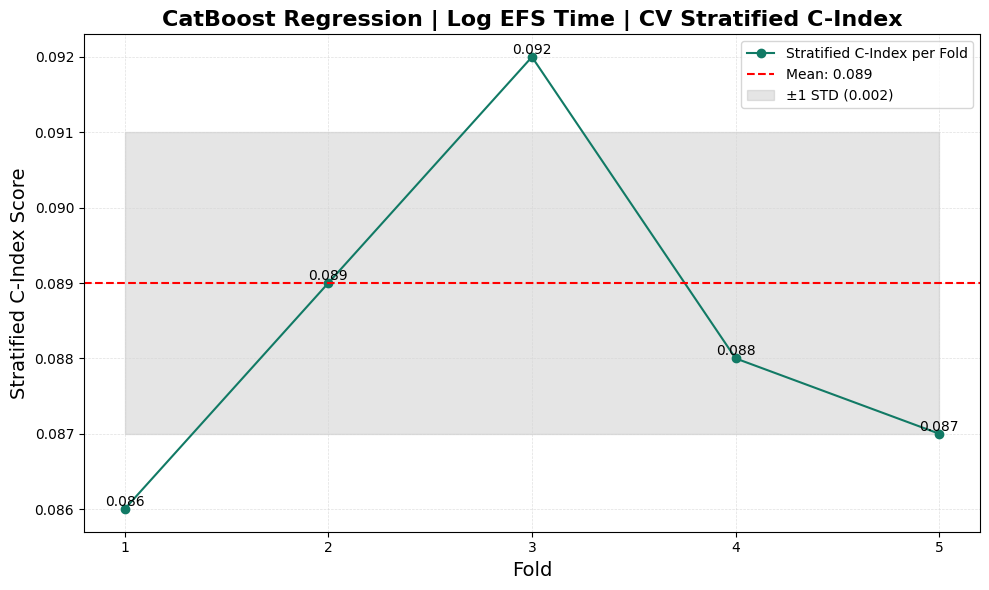

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 1 Stratified C-Index: 0.0884

Fold 2


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 2 Stratified C-Index: 0.0885

Fold 3


...

Fold 3 Stratified C-Index: 0.0949

Fold 4


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 4 Stratified C-Index: 0.0898

Fold 5


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 5 Stratified C-Index: 0.0872


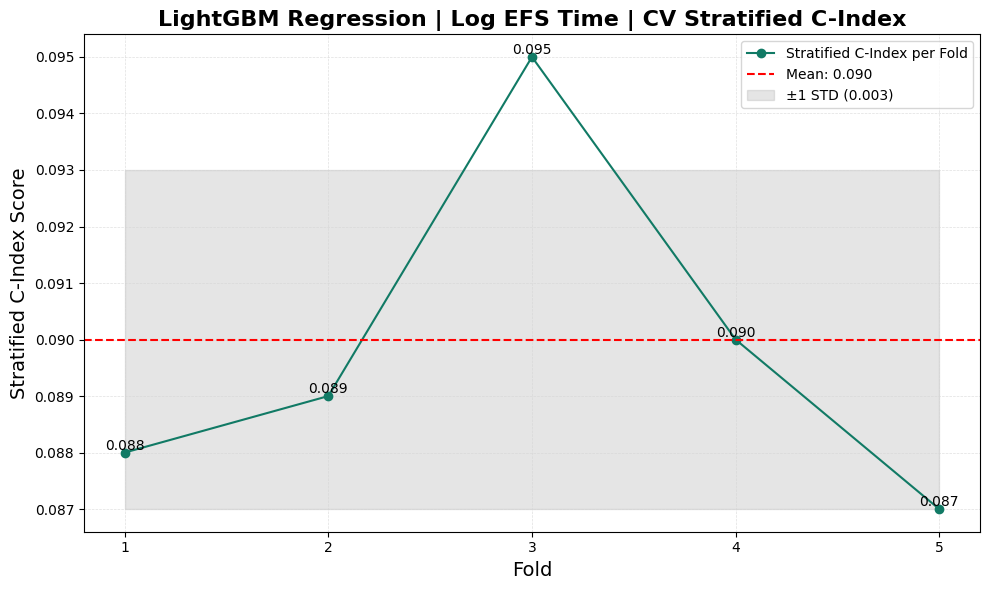

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0877

Fold 2
Fold 2 Stratified C-Index: 0.0854

Fold 3
Fold 3 Stratified C-Index: 0.0918

Fold 4
Fold 4 Stratified C-Index: 0.0908

Fold 5
Fold 5 Stratified C-Index: 0.0861


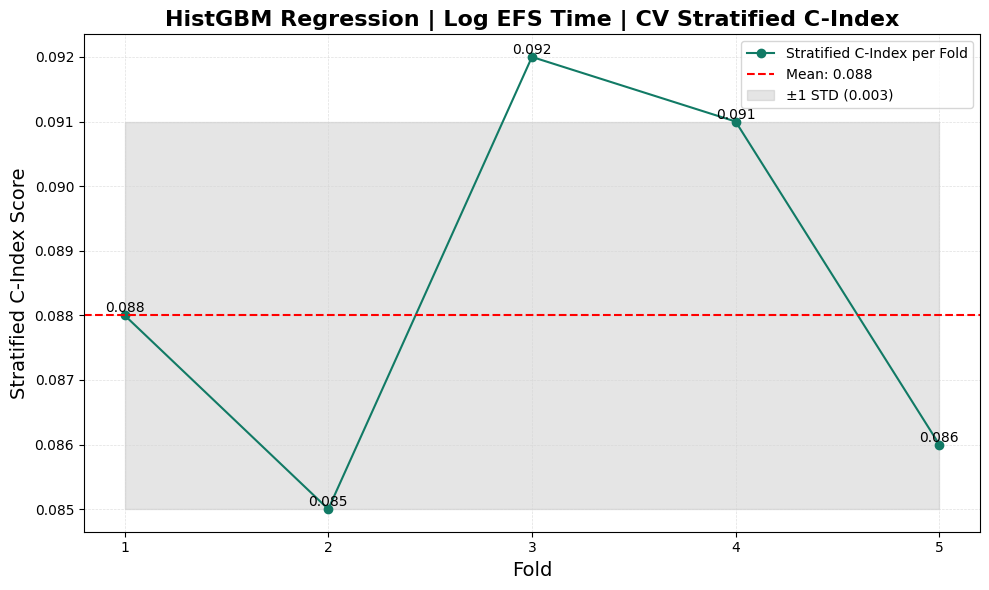

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.8915

Fold 2
Fold 2 Stratified C-Index: 0.8897

Fold 3
Fold 3 Stratified C-Index: 0.8888

Fold 4
Fold 4 Stratified C-Index: 0.8962

Fold 5
Fold 5 Stratified C-Index: 0.8928


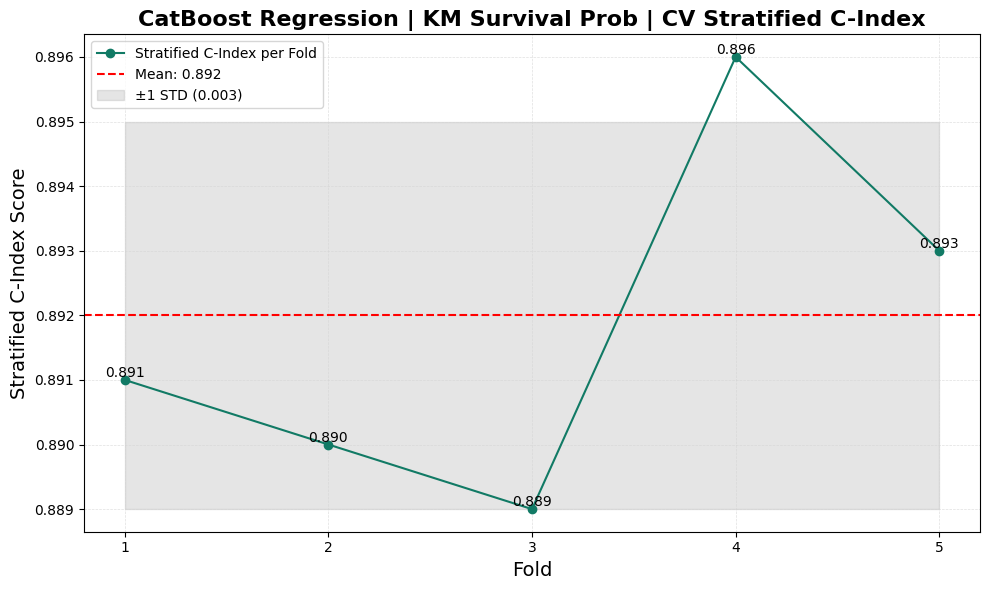

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 1 Stratified C-Index: 0.8883

Fold 2


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 2 Stratified C-Index: 0.8904

Fold 3


...

Fold 3 Stratified C-Index: 0.8863

Fold 4


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 4 Stratified C-Index: 0.8964

Fold 5


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 5 Stratified C-Index: 0.8928


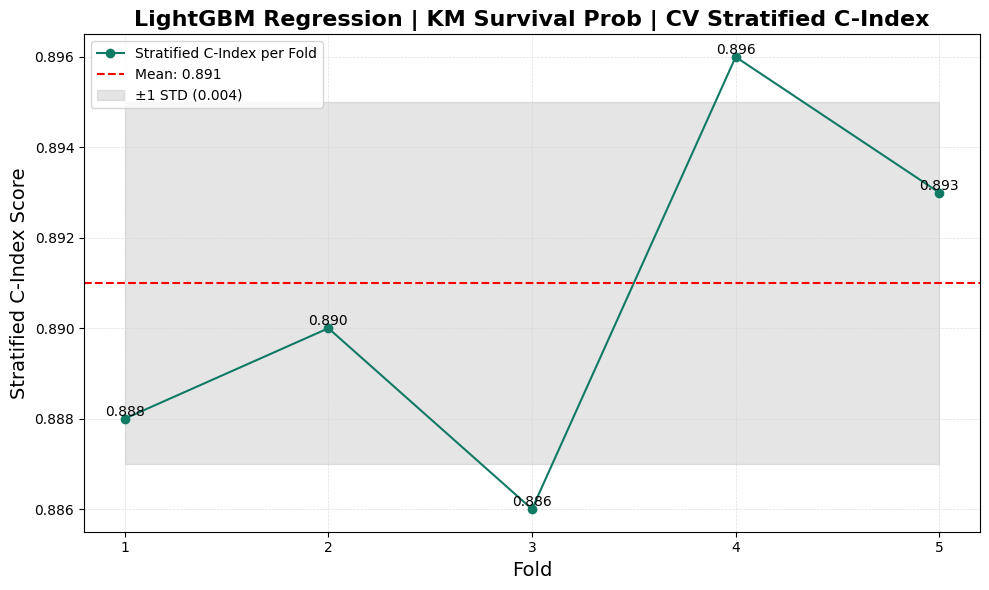

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.8882

Fold 2
Fold 2 Stratified C-Index: 0.8863

Fold 3
Fold 3 Stratified C-Index: 0.8852

Fold 4
Fold 4 Stratified C-Index: 0.8932

Fold 5
Fold 5 Stratified C-Index: 0.8855


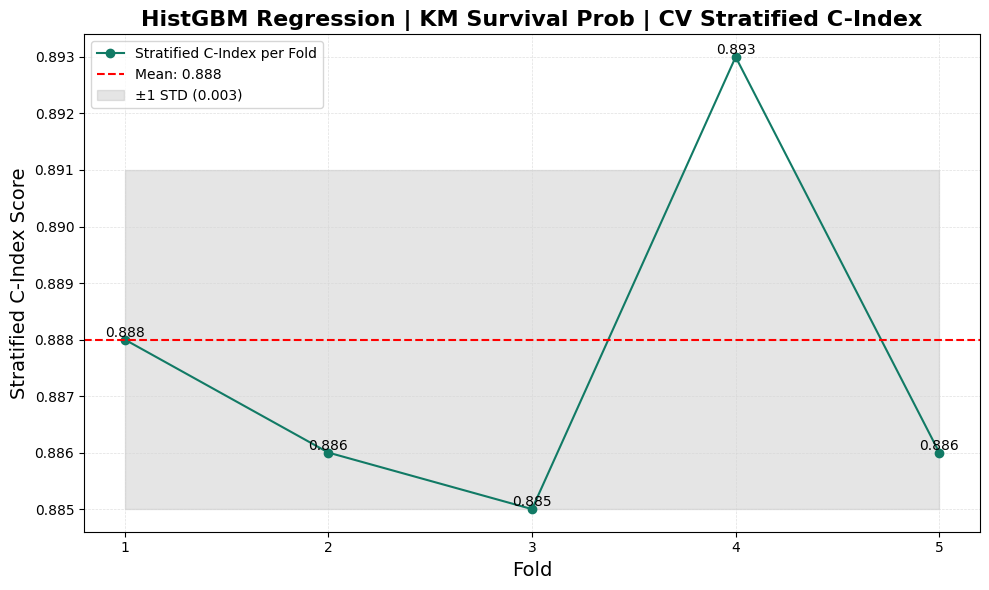

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0867

Fold 2
Fold 2 Stratified C-Index: 0.0908

Fold 3
Fold 3 Stratified C-Index: 0.0959

Fold 4
Fold 4 Stratified C-Index: 0.0882

Fold 5
Fold 5 Stratified C-Index: 0.0878


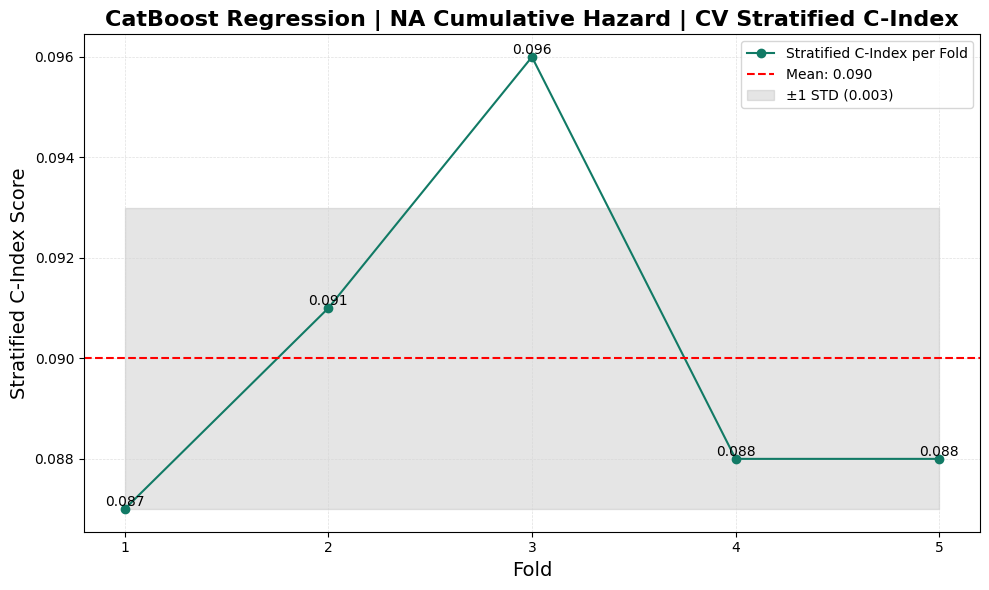

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 1 Stratified C-Index: 0.0900

Fold 2


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 2 Stratified C-Index: 0.0902

Fold 3


...

Fold 3 Stratified C-Index: 0.0959

Fold 4


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 4 Stratified C-Index: 0.0908

Fold 5


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 5 Stratified C-Index: 0.0886


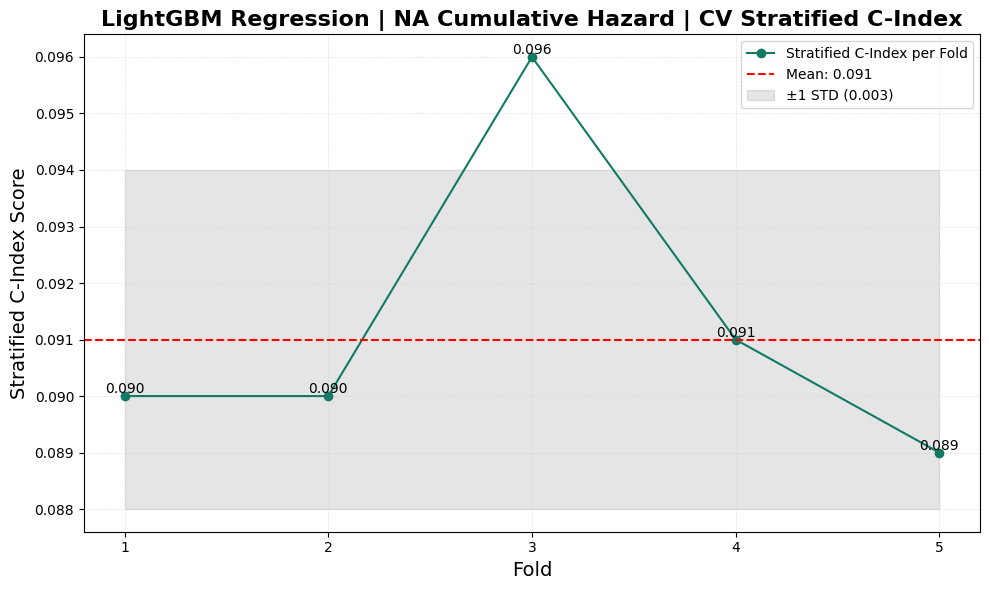

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0909

Fold 2
Fold 2 Stratified C-Index: 0.0916

Fold 3
Fold 3 Stratified C-Index: 0.0961

Fold 4
Fold 4 Stratified C-Index: 0.0912

Fold 5
Fold 5 Stratified C-Index: 0.0906


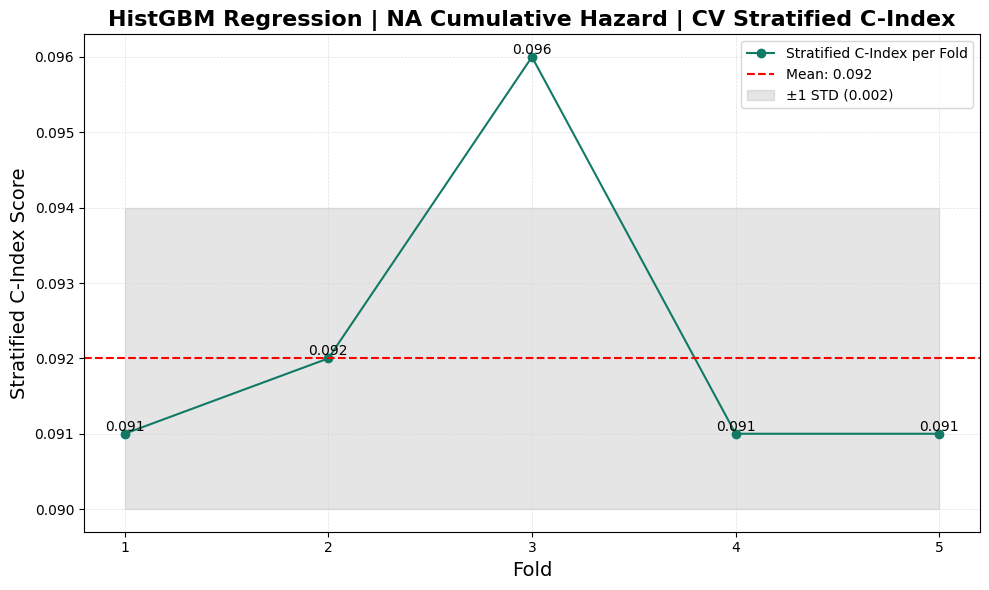

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0859

Fold 2
Fold 2 Stratified C-Index: 0.0890

Fold 3
Fold 3 Stratified C-Index: 0.0928

Fold 4
Fold 4 Stratified C-Index: 0.0871

Fold 5
Fold 5 Stratified C-Index: 0.0876


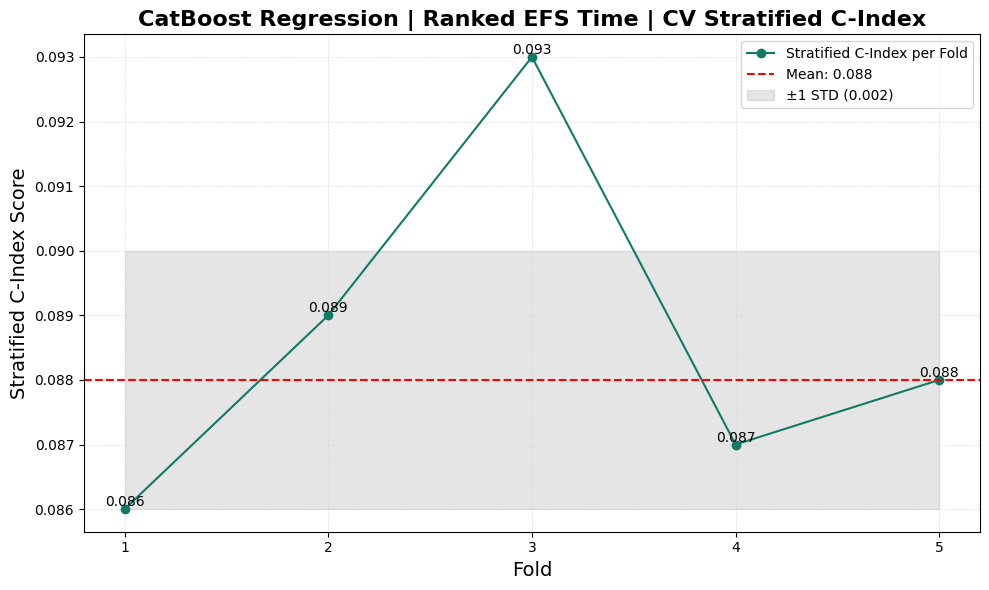

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 1 Stratified C-Index: 0.0881

Fold 2


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 2 Stratified C-Index: 0.0895

Fold 3


...

Fold 3 Stratified C-Index: 0.0901

Fold 4


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 4 Stratified C-Index: 0.0898

Fold 5


c:\Users\mattg\kaggle_env\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Fold 5 Stratified C-Index: 0.0891


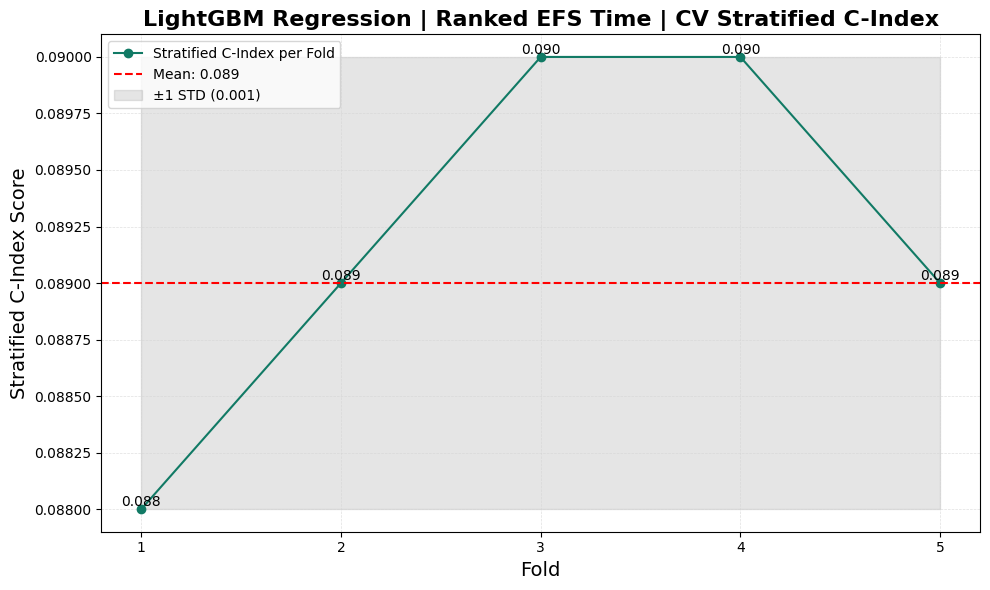

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Fold 1
Fold 1 Stratified C-Index: 0.0878

Fold 2
Fold 2 Stratified C-Index: 0.0901

Fold 3
Fold 3 Stratified C-Index: 0.0929

Fold 4
Fold 4 Stratified C-Index: 0.0895

Fold 5
Fold 5 Stratified C-Index: 0.0881


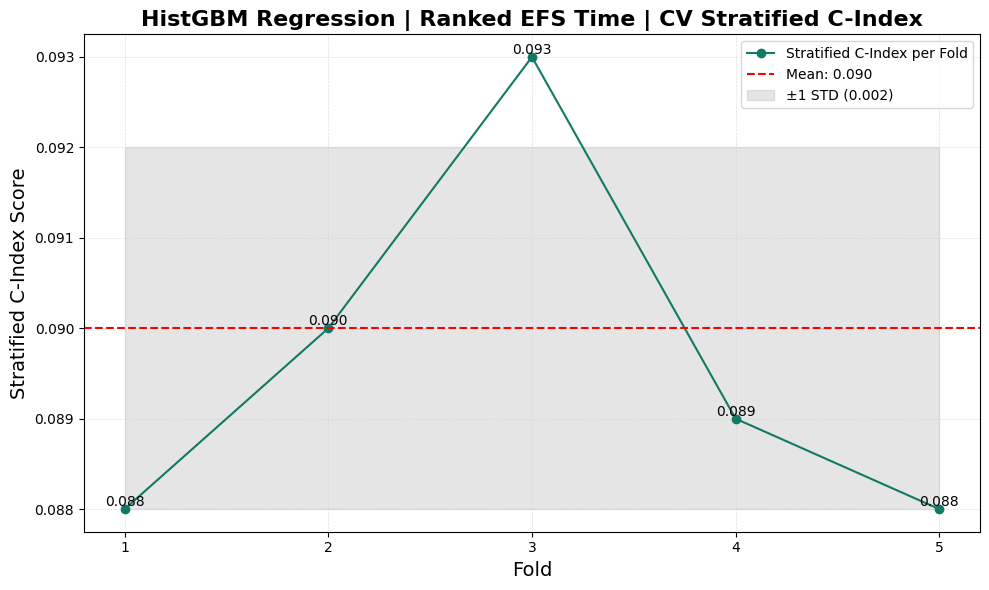

extra features in test data (will be dropped): ['ID', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']


In [ ]:
model_configs_tree = [
    # classification models (predicting EFS binary outcome)
    {"model_type": "CatBoost", "params": CFG.ctb_class_params, "target": "efs", "is_classifier": True, "title": "CatBoost Classification | EFS"},
    {"model_type": "XGBoost", "params": CFG.xgb_class_params, "target": "efs", "is_classifier": True, "title": "XGBoost Classification | EFS"},
    {"model_type": "LightGBM", "params": CFG.lgb_class_params, "target": "efs", "is_classifier": True, "title": "LightGBM Classification | EFS"},
    {"model_type": "HistGBM", "params": CFG.hist_class_params, "target": "efs", "is_classifier": True, "title": "HistGBM Classification | EFS"},

    # regression models (predicting log EFS time)
    {"model_type": "CatBoost", "params": CFG.cat_reg_params, "target": "log_efs_time", "is_classifier": False, "title": "CatBoost Regression | Log EFS Time"},
    #{"model_type": "XGBoost", "params": CFG.xgb_reg_log_EFSTime_params, "target": "log_efs_time", "is_classifier": False, "title": "XGBoost Regression | Log EFS Time"},
    {"model_type": "LightGBM", "params": CFG.lgb_reg_params, "target": "log_efs_time", "is_classifier": False, "title": "LightGBM Regression | Log EFS Time"},
    {"model_type": "HistGBM", "params": CFG.hist_reg_log_EFSTime_params, "target": "log_efs_time", "is_classifier": False, "title": "HistGBM Regression | Log EFS Time"},

    # regression models (predicting Kaplan-Meier survival probability)
    {"model_type": "CatBoost", "params": CFG.cat_reg_params, "target": "km_survival_prob", "is_classifier": False, "title": "CatBoost Regression | KM Survival Prob"},
    #{"model_type": "XGBoost", "params": CFG.xgb_reg_KM_params, "target": "km_survival_prob", "is_classifier": False, "title": "XGBoost Regression | KM Survival Prob"},
    {"model_type": "LightGBM", "params": CFG.lgb_reg_params, "target": "km_survival_prob", "is_classifier": False, "title": "LightGBM Regression | KM Survival Prob"},
    {"model_type": "HistGBM", "params": CFG.hist_reg_KMSurv_params, "target": "km_survival_prob", "is_classifier": False, "title": "HistGBM Regression | KM Survival Prob"},

    # regression models (predicting Nelson-Aalen cumulative hazard)
    {"model_type": "CatBoost", "params": CFG.cat_reg_params, "target": "na_cum_hazard", "is_classifier": False, "title": "CatBoost Regression | NA Cumulative Hazard"},
    #{"model_type": "XGBoost", "params": CFG.xgb_reg_KM_params, "target": "na_cum_hazard", "is_classifier": False, "title": "XGBoost Regression | NA Cumulative Hazard"},
    {"model_type": "LightGBM", "params": CFG.lgb_reg_params, "target": "na_cum_hazard", "is_classifier": False, "title": "LightGBM Regression | NA Cumulative Hazard"},
    {"model_type": "HistGBM", "params": CFG.hist_reg_NACumHaz_params, "target": "na_cum_hazard", "is_classifier": False, "title": "HistGBM Regression | NA Cumulative Hazard"},

    # regression models (predicting ranked EFS time)
    {"model_type": "CatBoost", "params": CFG.cat_reg_params, "target": "ranked_efs_time", "is_classifier": False, "title": "CatBoost Regression | Ranked EFS Time"},
    #{"model_type": "XGBoost", "params": CFG.xgb_reg_log_EFSTime_params, "target": "ranked_efs_time", "is_classifier": False, "title": "XGBoost Regression | Ranked EFS Time"},
    {"model_type": "LightGBM", "params": CFG.lgb_reg_params, "target": "ranked_efs_time", "is_classifier": False, "title": "LightGBM Regression | Ranked EFS Time"},
    {"model_type": "HistGBM", "params": CFG.hist_reg_log_EFSTime_params, "target": "ranked_efs_time", "is_classifier": False, "title": "HistGBM Regression | Ranked EFS Time"},
]

models_tree, oof_preds_tree, test_preds_tree = train_and_predict(md_tree, model_configs_tree, test_tree['X'])

In [13]:
train_cox_df.columns

Index(['ID', 'dri_score', 'psych_disturb', 'cyto_score', 'diabetes',
       'hla_match_c_high', 'hla_high_res_8', 'tbi_status', 'arrhythmia',
       'hla_low_res_6',
       ...
       'cardiac_Not done', 'cardiac_Unknown', 'cardiac_Yes',
       'pulm_moderate_No', 'pulm_moderate_Not done', 'pulm_moderate_Unknown',
       'pulm_moderate_Yes', 'efs', 'efs_time', 'race_group'],
      dtype='object', length=252)

Training Fold 1
Epoch 1/100, Loss: 2.6706
Epoch 2/100, Loss: 2.6709
Epoch 3/100, Loss: 2.6702
Epoch 4/100, Loss: 2.6708
Epoch 5/100, Loss: 2.6706
Epoch 6/100, Loss: 2.6698
Epoch 7/100, Loss: 2.6521
Epoch 8/100, Loss: 2.6365
Epoch 9/100, Loss: 2.6248
Epoch 10/100, Loss: 2.6163
Epoch 11/100, Loss: 2.6093
Epoch 12/100, Loss: 2.6009
Epoch 13/100, Loss: 2.5916
Epoch 14/100, Loss: 2.5812
Epoch 15/100, Loss: 2.5685
Epoch 16/100, Loss: 2.5557
Epoch 17/100, Loss: 2.5430
Epoch 18/100, Loss: 2.5289
Epoch 19/100, Loss: 2.5169
Epoch 20/100, Loss: 2.5055
Epoch 21/100, Loss: 2.4936
Epoch 22/100, Loss: 2.4813
Epoch 23/100, Loss: 2.4685
Epoch 24/100, Loss: 2.4559
Epoch 25/100, Loss: 2.4431
Epoch 26/100, Loss: 2.4305
Epoch 27/100, Loss: 2.4174
Epoch 28/100, Loss: 2.4047
Epoch 29/100, Loss: 2.3922
Epoch 30/100, Loss: 2.3812
Epoch 31/100, Loss: 2.3701
Epoch 32/100, Loss: 2.3577
Epoch 33/100, Loss: 2.3465
Epoch 34/100, Loss: 2.3365
Epoch 35/100, Loss: 2.3272
Epoch 36/100, Loss: 2.3181
Epoch 37/100, Loss: 2

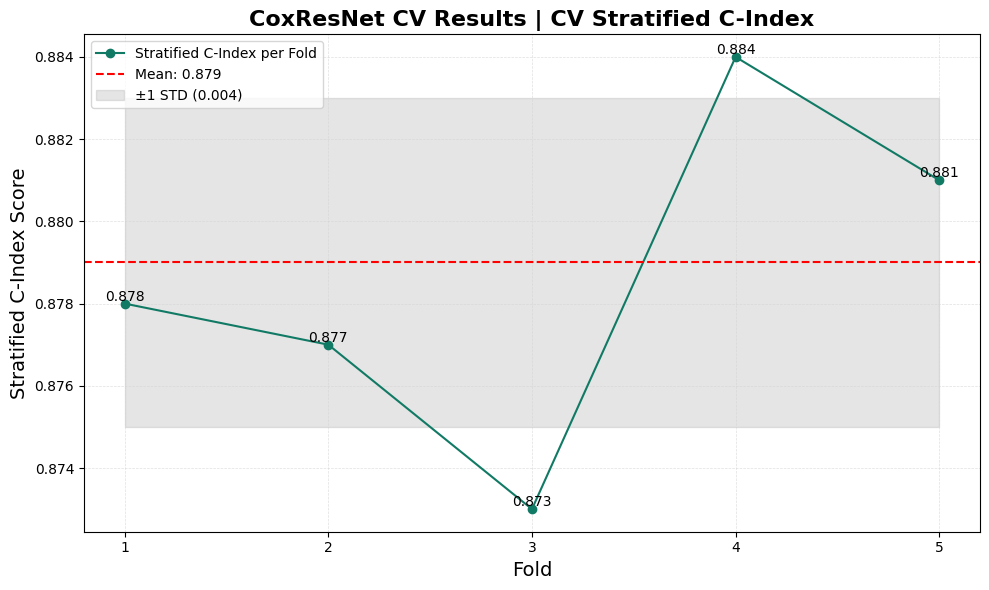


Final OOF Predictions: [-5.50958872  4.39623594 -5.94559479 ... -3.81305218 -3.17276049
 -6.14368439]
converting race_group to int before inference
extra features in test data (will be dropped): ['ID', 'race_group', 'log_efs_time', 'ranked_efs_time', 'km_survival_prob', 'na_cum_hazard', 'neg_exp_na_cum_hazard', 'target_norm']

Final Test Predictions: [5.62280816 5.11456293 5.18294466]
[array([-5.50958872,  4.39623594, -5.94559479, ..., -3.81305218,
       -3.17276049, -6.14368439])]
[array([5.62280816, 5.11456293, 5.18294466])]


In [14]:
# model configs
model_configs_cox = [{"model_type": "CoxResNet", "target": "log_efs_time", "is_classifier": False,   "title": "CoxResNet Regression | Log EFS Time"}]

# train and predict 
models_cox, oof_preds_cox, test_preds_cox = train_and_predict(md_cox, model_configs_cox, test_cox['X'])
print(oof_preds_cox)
print(test_preds_cox)

### Checking Correlations (efs_time vs. Model Outputs)

Here, I calculate how strongly each model’s OOF predictions correlate with `efs_time` (restricted to rows where `efs=1`). A positive correlation typically means “bigger predictions = longer survival,” while negative correlation is the reverse. This step helps me decide whether I need sign flipping for certain regressors, to make sure that the final aggregator treats predictions in the correct orientation.

Why “bigger = longer survival” vs. “bigger = earlier event” Matters:

The official c-index code does concordance_index(XYZ, -prediction, XYZ)  That means if your model’s “bigger” means “longer survival,” then -prediction is “lower hazard.” All is good. However, if your model’s “bigger” means “earlier event,” then the sign is reversed from the official code’s assumption. You might want to multiply by -1 somewhere (in ensemble.py for the corresponding regessor) so that “bigger = longer survival” at submission time.

In [15]:
def calculate_correlation(oof_preds, train_df, target_name):
    """ Calculates and prints the correlation between predicted values and efs_time for efs=1 """
    mask = (train_df['efs'] == 1)
    efs_time_events = train_df.loc[mask, 'efs_time']
    oof_events = oof_preds[mask]
    corr = np.corrcoef(oof_events, efs_time_events)[0, 1]
    print(f"Correlation with efs_time among efs=1 for {target_name}: {corr:.4f}")


# indices for each target using catboost regression 
target_indices = {"Log EFS Time Target": 4,  "KM OOF preds": 7, "NA OOF preds": 10, "Ranked EFS Time OOF preds": 13}

for target_name, index in target_indices.items():
    oof_preds = oof_preds_tree[index]
    calculate_correlation(oof_preds, train_tree_df, target_name)

Correlation with efs_time among efs=1 for Log EFS Time Target: 0.4745
Correlation with efs_time among efs=1 for KM OOF preds: -0.4675
Correlation with efs_time among efs=1 for NA OOF preds: 0.4726
Correlation with efs_time among efs=1 for Ranked EFS Time OOF preds: 0.4730


In [16]:
# indices for each target
target_indices = {"Log EFS Time Target": 0}

for target_name, index in target_indices.items():
    oof_preds = oof_preds_cox[index]
    calculate_correlation(oof_preds, train_cox_df, target_name)

Correlation with efs_time among efs=1 for Log EFS Time Target: -0.3844


In [ ]:
best_merge_params = optimize_merge_params(oof_preds_tree, oof_preds_cox, test_preds_tree, test_preds_cox, train_tree, subm_path=CFG.subm_path, output_name="submission.csv", n_trials=4000)

In [18]:
final_submission = pd.read_csv("submission.csv")
final_submission.head()

,ID,prediction
0,28800,0.666667
1,28801,1.000000
2,28802,0.333333
